# Heat conduction around solid particles: grid convergence of the immersed boundary method

A fluid of thermal conductivity $k$ occupies a square domain containing solid
particles (disks).  At every particle surface a **Robin (contact-conductance)
condition** couples the outward heat flux to the surface temperature,

$$ k\,\frac{\partial T}{\partial n_\text{out}} + h\,T_\Gamma \;=\; d , $$

with $h$ a surface heat-transfer coefficient and $n_\text{out}$ the outward
(fluid-side) direction.  We solve the steady conduction equation
$-\nabla\!\cdot\!(k\nabla T) = q$ and study the **grid convergence** of the
immersed-boundary discretisation — in particular what happens when two
particles **touch**.

The same physical problem is discretised in **two ways**:

1. **Full SDF description** — the classical route: one global signed-distance
   field `sdf = min_i(dist_i)` sampled at the cell centres;
   `construct_ibm(sdf, ...)` locates the walls by linear interpolation of the
   SDF and `construct_ibm_normal_derivative` takes the surface normals from the
   SDF gradient.
2. **Particle description** — the circles are described *analytically* by
   `pymrm.Circle` objects; `construct_ibm_particles` computes exact
   wall positions (quadratic solve per cut face) and exact outward normals.

A **manufactured temperature field** $T^*$ defines the source $q$, the domain
wall temperatures, and the Robin data $d$, so the exact solution is known on
every grid for *any* particle arrangement — including exact contact, where no
analytic solution exists.

## 1. Manufactured solution and helpers

$$ T^*(x,y) = 300 + 20\cos(1.3\pi x)\cos(0.8\pi y) + 8x + 5y \quad [\mathrm{K}] $$

with $k = 2.5\ \mathrm{W\,m^{-1}K^{-1}}$ and $h = 8\ \mathrm{W\,m^{-2}K^{-1}}$.
The volumetric source is $q = -k\nabla^2 T^*$; the domain walls are held at
$T^*$; the Robin data is $d = k\,\partial T^*/\partial n_\text{out} + h\,T^*$
evaluated at the wall crossings **with the exact geometric normal** — the
problem data is identical for both discretisations, only the geometric
information *inside the method* differs.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_array
from scipy.sparse.linalg import spsolve

from pymrm import (construct_grad, construct_div, construct_ibm, apply_ibm,
                   apply_ibm_vector, construct_ibm_normal_derivative,
                   construct_ibm_boundary_values, Circle,
                   construct_ibm_particles)
from pymrm.ibm_recon import interface_normals

K_COND = 2.5      # fluid thermal conductivity  [W/m/K]
H_SURF = 8.0      # surface heat-transfer coefficient  [W/m^2/K]
KX, KY = 1.3 * np.pi, 0.8 * np.pi
Ns = [40, 80, 160, 320]          # grid sequence (reduce for a faster run)

def T_star(x, y):
    return 300.0 + 20.0 * np.cos(KX * x) * np.cos(KY * y) + 8.0 * x + 5.0 * y

def grad_T_star(x, y):
    return (-20.0 * KX * np.sin(KX * x) * np.cos(KY * y) + 8.0,
            -20.0 * KY * np.cos(KX * x) * np.sin(KY * y) + 5.0)

def source(x, y):                        # q = -k lap T*
    return 20.0 * K_COND * (KX**2 + KY**2) * np.cos(KX * x) * np.cos(KY * y)

def make_grid(N):
    x_f = [np.linspace(0.0, 1.0, N + 1), np.linspace(0.0, 1.0, N + 1)]
    x_c = [0.5 * (xf[:-1] + xf[1:]) for xf in x_f]
    X, Y = np.meshgrid(x_c[0], x_c[1], indexing="ij")
    return x_f, x_c, X, Y

def err_norms(T, T_ex, fluid, h):
    e = (T - T_ex)[fluid]
    return (np.sum(np.abs(e)) * h * h,
            np.sqrt(np.sum(e**2) * h * h),
            np.abs(e).max())

def order(errs):
    return [float("nan")] + [np.log(errs[k-1] / errs[k]) / np.log(2)
                             for k in range(1, len(errs))]

def report(label, results):
    print(f"\n=== {label} ===")
    print(f"{'N':>5} {'L1':>11} {'ord':>5} {'L2':>11} {'ord':>5} "
          f"{'Linf':>11} {'ord':>5}")
    o1, o2, oi = (order([r[j] for r in results]) for j in range(3))
    for k, N in enumerate(Ns):
        print(f"{N:>5} {results[k][0]:>11.3e} {o1[k]:>5.2f} "
              f"{results[k][1]:>11.3e} {o2[k]:>5.2f} "
              f"{results[k][2]:>11.3e} {oi[k]:>5.2f}")
    return [r[1] for r in results]        # L2 errors for the figure

## 2. Geometries

A single disk, and two disks in **exact contact**.  Both are defined once as
`(centre, radius)` pairs; the SDF route derives the union field from them, the
particle route wraps them in analytic `Circle` objects.  The exact outward
normal of the *owning* disk provides the Robin problem data in both cases.

In [2]:
DISKS_SINGLE = [((0.503, 0.497), 0.28)]
R_T = 0.22
DISKS_TOUCH = [((0.5 - R_T, 0.5015), R_T), ((0.5 + R_T, 0.5015), R_T)]

def union_sdf(disks, X, Y):
    return np.minimum.reduce(
        [np.hypot(X - cx, Y - cy) - r for (cx, cy), r in disks])

def exact_normals(coords, disks):
    '''Outward unit normal of the disk whose surface is nearest.'''
    n = np.zeros_like(coords)
    best = np.full(len(coords), np.inf)
    for (cx, cy), r in disks:
        dist = np.abs(np.hypot(coords[:, 0] - cx, coords[:, 1] - cy) - r)
        take = dist < best
        best[take] = dist[take]
        v = coords[take] - np.array([cx, cy])
        n[take] = v / np.linalg.norm(v, axis=1, keepdims=True)
    return n

## 3. Shared discretisation

One solver serves both geometry descriptions.  It receives the immersed
boundary data (`ibm`), a field for fluid/solid classification in the
reconstruction, and optionally overriding normals; everything else — the
conduction operator $-\nabla\cdot(k\nabla T)$ with Dirichlet $T^*$ domain
walls, identity rows in the (unmodelled) solid, the GFD flux reconstruction,
and the Robin elimination — is identical:

$$ A\,T = b, \qquad A = A_\text{ibm} + G_\text{out} H, $$

with $H$ from `construct_ibm_boundary_values` expressing the surface
temperature $T_\Gamma$ in terms of the fluid field.

In [3]:
def solve_heat(N, disks, geometry):
    '''geometry(N, disks) -> (ibm, sdf_for_recon, normals_or_None, solid_mask)'''
    x_f, x_c, X, Y = make_grid(N)
    ibm, sdf_recon, normals, solid = geometry(N, disks)

    # conduction operator with Dirichlet T* domain walls
    shape = (N, N)
    diff = csc_array((N * N, N * N)); g_bc = np.zeros((N * N, 1))
    for i in range(2):
        if i == 0:
            bc = ({'a': 0, 'b': 1, 'd': T_star(0.0, x_c[1])[None, :]},
                  {'a': 0, 'b': 1, 'd': T_star(1.0, x_c[1])[None, :]})
        else:
            bc = ({'a': 0, 'b': 1, 'd': T_star(x_c[0], 0.0)[:, None]},
                  {'a': 0, 'b': 1, 'd': T_star(x_c[0], 1.0)[:, None]})
        gm, gb = construct_grad(shape, x_f[i], x_c[i], bc=bc, axis=i, format='csc')
        dv = construct_div(shape, x_f[i], axis=i, format='csc')
        diff = diff + dv @ (-K_COND * gm)
        g_bc = g_bc + dv @ (-K_COND * gb)
    g_bc = np.asarray(g_bc).reshape(-1)
    q = source(X, Y).reshape(-1)

    fluid = ~solid.reshape(-1)
    diff = diff.tolil()                       # unmodelled solid -> identity rows
    for r in np.flatnonzero(~fluid):
        diff.rows[r] = [r]; diff.data[r] = [1.0]
    diff = diff.tocsc()
    rhs0 = np.where(fluid, q - g_bc, 0.0)

    # flux reconstruction + Robin elimination at the particle surfaces
    recon = construct_ibm_normal_derivative(ibm, sdf_recon, x_c, normals=normals)
    ne = exact_normals(ibm.coords, disks)     # problem data: exact geometry
    gx, gy = grad_T_star(ibm.coords[:, 0], ibm.coords[:, 1])
    q_out_star = -(gx * ne[:, 0] + gy * ne[:, 1])
    d_rob = K_COND * q_out_star + H_SURF * T_star(ibm.coords[:, 0],
                                                  ibm.coords[:, 1])

    A_ibm, G_out, G_in = apply_ibm(diff, ibm, return_bc="matrix")
    H, h_vec = construct_ibm_boundary_values(
        ibm, recon, {'a': K_COND, 'b': H_SURF, 'd': d_rob}, side='out')
    A = (A_ibm + G_out @ H).tocsr()
    b = apply_ibm_vector(rhs0, ibm) - np.asarray(G_out @ h_vec).ravel()
    T = spsolve(A.tocsc(), b)
    return err_norms(T, T_star(X, Y).reshape(-1), fluid, 1.0 / N)

## 4. Method 1 — full SDF description

The union SDF is sampled at the cell centres; wall positions come from linear
interpolation of the SDF along each cut face, and the surface normals from
the interpolated SDF gradient (`interface_normals`, the library default).

In [4]:
def geometry_sdf(N, disks):
    x_f, x_c, X, Y = make_grid(N)
    sdf = union_sdf(disks, X, Y)
    ibm = construct_ibm(sdf, x_c)
    return ibm, sdf, None, (sdf < 0)

res_sdf_single = [solve_heat(N, DISKS_SINGLE, geometry_sdf) for N in Ns]
res_sdf_touch = [solve_heat(N, DISKS_TOUCH, geometry_sdf) for N in Ns]
L2_sdf_single = report("SDF  |  single disk", res_sdf_single)
L2_sdf_touch = report("SDF  |  two touching disks", res_sdf_touch)


=== SDF  |  single disk ===
    N          L1   ord          L2   ord        Linf   ord
   40   3.679e-03   nan   5.887e-03   nan   2.824e-02   nan
   80   8.819e-04  2.06   1.391e-03  2.08   5.806e-03  2.28
  160   2.165e-04  2.03   3.443e-04  2.01   1.364e-03  2.09
  320   5.568e-05  1.96   8.835e-05  1.96   3.582e-04  1.93

=== SDF  |  two touching disks ===
    N          L1   ord          L2   ord        Linf   ord
   40   1.480e-02   nan   4.018e-02   nan   5.509e-01   nan
   80   7.756e-03  0.93   2.406e-02  0.74   5.087e-01  0.11
  160   3.286e-03  1.24   1.116e-02  1.11   3.695e-01  0.46
  320   1.339e-03  1.29   5.073e-03  1.14   2.585e-01  0.52


The single disk converges at the expected **2nd order**.  For the
touching disks the order collapses to **~1 in L2** (and ~0.5 in the maximum
norm): the union SDF is not differentiable on the contact medial axis, so the
SDF-gradient normals carry an O(1) error in a fixed cluster of crossings at
the contact, and the interpolated wall positions there are polluted by the
*other* disk's distance field.

## 5. Method 2 — analytic particle description

The same disks as `Circle` particles: `construct_ibm_particles` classifies the
cells per particle (bounding-box windows), computes each cut-face wall
position **exactly** (quadratic solve on the owning circle) and returns the
**exact outward normals** in `info.normals`.  The `info.pseudo_sdf` field
(sign-correct union) serves the fluid/solid classification of the
reconstruction; sub-cell gaps at the contact are walled off by the default
``contact="no_flux"`` policy (inert here, since the solid is not modelled).

In [5]:
def geometry_particles(N, disks):
    x_f, x_c, X, Y = make_grid(N)
    parts = [Circle(c, r) for c, r in disks]
    ibm, info = construct_ibm_particles(parts, x_c)
    return ibm, info.pseudo_sdf, info.normals, (info.owner >= 0)

res_p_single = [solve_heat(N, DISKS_SINGLE, geometry_particles) for N in Ns]
res_p_touch = [solve_heat(N, DISKS_TOUCH, geometry_particles) for N in Ns]
L2_p_single = report("Particles  |  single disk", res_p_single)
L2_p_touch = report("Particles  |  two touching disks", res_p_touch)


=== Particles  |  single disk ===
    N          L1   ord          L2   ord        Linf   ord
   40   3.839e-03   nan   6.122e-03   nan   2.903e-02   nan
   80   9.214e-04  2.06   1.451e-03  2.08   5.993e-03  2.28
  160   2.258e-04  2.03   3.580e-04  2.02   1.400e-03  2.10
  320   5.791e-05  1.96   9.170e-05  1.96   3.677e-04  1.93

=== Particles  |  two touching disks ===
    N          L1   ord          L2   ord        Linf   ord
   40   3.542e-03   nan   7.599e-03   nan   1.408e-01   nan
   80   8.649e-04  2.03   1.907e-03  1.99   5.151e-02  1.45
  160   2.474e-04  1.81   5.998e-04  1.67   2.410e-02  1.10
  320   6.433e-05  1.94   1.639e-04  1.87   1.001e-02  1.27


The particle description leaves the single disk unchanged (~2nd order,
marginally smaller constants from the exact walls) and **restores the touching
case to ~1.8 in L2**, reducing the error by more than an order of magnitude on
the finer grids.

## 6. Convergence comparison

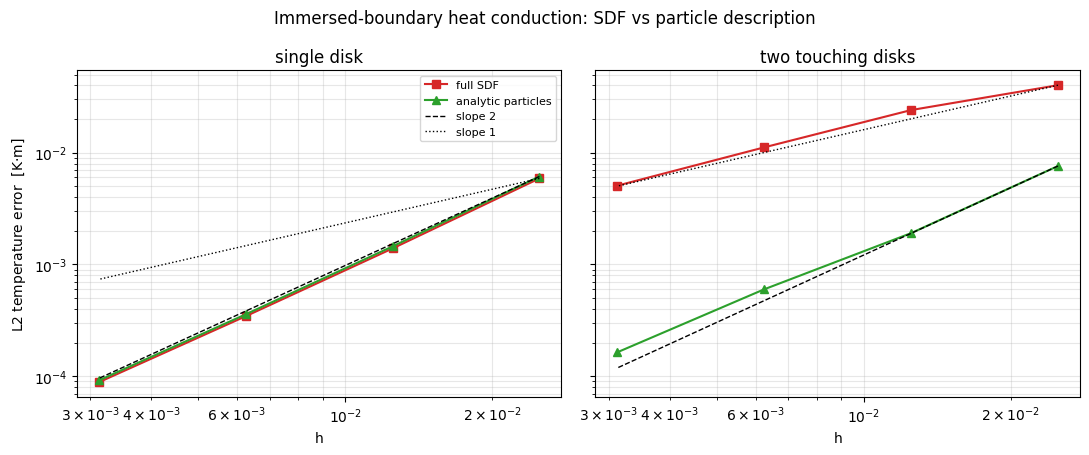

In [6]:
h = np.array([1.0 / N for N in Ns])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)

for a, (l_sdf, l_p, title) in zip(
        ax, [(L2_sdf_single, L2_p_single, "single disk"),
             (L2_sdf_touch, L2_p_touch, "two touching disks")]):
    a.loglog(h, l_sdf, 's-', color='tab:red', label='full SDF')
    a.loglog(h, l_p, '^-', color='tab:green', label='analytic particles')
    a.loglog(h, l_p[0] * (h / h[0])**2, 'k--', lw=1, label='slope 2')
    a.loglog(h, l_sdf[0] * (h / h[0])**1, 'k:', lw=1, label='slope 1')
    a.set(xlabel='h', title=title)
    a.grid(True, which='both', alpha=0.3)
ax[0].set_ylabel(r'L2 temperature error  [K$\cdot$m]')
ax[0].legend(fontsize=8)
fig.suptitle('Immersed-boundary heat conduction: SDF vs particle description')
fig.tight_layout(); plt.show()

## 7. Where the difference comes from

Two localized geometry errors of the SDF route at the contact, neither of
which is a stencil problem:

* **Normals** — the union SDF has a gradient kink on the contact medial axis;
  differencing across it tilts the normals by an O(1) angle in a fixed cluster
  of crossings (only shrinking as O(h) with resolution).  The analytic
  particle normals are exact.
* **Wall positions** — the interpolated ``theta`` uses the union value at the
  ghost cell, which near the contact belongs to the *other* disk.  The
  particle route intersects each face with the owning circle exactly.

The GFD flux stencils themselves stay healthy (hardly any degree demotion,
no unresolved crossings):

In [7]:
for N in Ns:
    x_f, x_c, X, Y = make_grid(N)
    sdf = union_sdf(DISKS_TOUCH, X, Y)
    ibm = construct_ibm(sdf, x_c)
    parts = [Circle(c, r) for c, r in DISKS_TOUCH]
    ibm_p, info = construct_ibm_particles(parts, x_c)
    reg = ~info.contact          # regular crossings: on a particle surface
    # (contact crossings sit at the mid-gap point by construction and their
    #  normal points towards the partner particle - excluded here)

    ne = exact_normals(ibm.coords, DISKS_TOUCH)
    ang = lambda a, b: np.degrees(np.arccos(np.clip(np.sum(a * b, 1), -1, 1)))
    a_sdf = ang(interface_normals(ibm, sdf, x_c), ne)
    a_p = ang(info.normals[reg],
              exact_normals(ibm_p.coords[reg], DISKS_TOUCH))
    on_circle = np.minimum.reduce(
        [np.abs(np.hypot(ibm_p.coords[reg, 0] - cx,
                         ibm_p.coords[reg, 1] - cy) - r)
         for (cx, cy), r in DISKS_TOUCH])
    recon = construct_ibm_normal_derivative(ibm, sdf, x_c)
    print(f"N={N:4d}  normal err (deg): sdf max {a_sdf.max():6.2f}"
          f"  particles max {a_p.max():.1e}   "
          f"particle wall off-surface: {on_circle.max():.1e}   "
          f"degree<2: {int((recon.degree_out < 2).sum())}, "
          f"unresolved: {int(recon.unresolved_out.sum())}")

N=  40  normal err (deg): sdf max  15.62  particles max 1.2e-06   particle wall off-surface: 5.6e-17   degree<2: 6, unresolved: 0


N=  80  normal err (deg): sdf max  12.23  particles max 1.5e-06   particle wall off-surface: 5.6e-17   degree<2: 8, unresolved: 0


N= 160  normal err (deg): sdf max   9.13  particles max 1.2e-06   particle wall off-surface: 8.3e-17   degree<2: 8, unresolved: 0


N= 320  normal err (deg): sdf max   6.63  particles max 1.5e-06   particle wall off-surface: 8.3e-17   degree<2: 8, unresolved: 0


## 8. What the particle description provides beyond accuracy

At exact contact the two disks share solid cells, so a segmentation of the
union SDF sees **one** body.  The particle assembly keeps per-particle
ownership: `info.segmentation` labels the disks separately (enabling
per-particle surface conditions), and the sub-cell gap faces detected at the
contact are *walled off* by the default ``no_flux`` policy — if the solid
interiors were modelled (conjugate heat transfer), no matrix entry would
couple the two particles directly:

In [8]:
x_f, x_c, X, Y = make_grid(64)
parts = [Circle(c, r) for c, r in DISKS_TOUCH]
ibm_c, info_c = construct_ibm_particles(parts, x_c)
print('contact crossings walled off :', int(info_c.contact.sum()))
print('per-particle segment sizes   :', info_c.segmentation.sizes)

L = csc_array((64 * 64, 64 * 64))
for a in range(2):
    gm, _ = construct_grad((64, 64), x_f[a], x_c[a], axis=a, format='csc')
    dv = construct_div((64, 64), x_f[a], axis=a, format='csc')
    L = L + dv @ gm
A, _ = apply_ibm(L.tocsr(), ibm_c, values_outside=0.0, values_inside=0.0)
own = info_c.owner.ravel()
block = A[np.ix_(np.flatnonzero(own == 0), np.flatnonzero(own == 1))]
print('max |coupling| disk-1 rows x disk-2 cols:', np.abs(block).max())

contact crossings walled off : 8
per-particle segment sizes   : [622 622]
max |coupling| disk-1 rows x disk-2 cols: 0.0


## 9. Summary

| case | full SDF | analytic particles |
|---|---|---|
| single disk | ~2.0 | ~2.0 |
| two touching disks (L2) | **~1.0** | **~1.8** |

* The immersed **Robin/flux** discretisation is 2nd order for isolated
  particles under either description.
* At **particle contact** the full-SDF route degrades to ~1st order through
  purely *geometric* errors (kinked-gradient normals, polluted wall
  positions), not stencil failure.
* The **analytic particle description** removes both error sources and
  restores ~1.8 (L2) / ~1.25 (L∞); the residual gap to 2 is a genuine PDE
  singularity of the re-entrant contact corner, beyond any fixed-stencil
  scheme.
* The particle route additionally provides per-particle segmentation at
  contact and the `no_flux` contact policy for conjugate problems.
* (The Dirichlet ghost-cell method `apply_ibm` is insensitive to all of this —
  it is 2nd order even for touching particles, as it uses no normals.)